# Comparison of ML and CNN with Advanced Sparse Compressive Techniques for Image Reconstruction

# Imporiting Libaries

In [2]:
pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.5 MB/s eta 0:00:00


In [3]:
# System
import os                     # I imported os to handle file and directory operations.
import warnings               # I imported warnings to suppress unnecessary output messages.
import logging                # I imported logging to silence library logs.
import numpy as np            # I imported NumPy to perform numerical computations and array operations.

warnings.filterwarnings("ignore")                 # I suppressed warning messages for cleaner outputs.
logging.getLogger("torchvision").setLevel(logging.ERROR)   # I disabled torchvision logs.
logging.getLogger("PIL").setLevel(logging.ERROR)           # I disabled PIL logs.

# Visualization
import matplotlib.pyplot as plt   # I imported matplotlib to visualize images and plots.

# Image Processing
import cv2             # I imported OpenCV to perform image processing tasks.
from PIL import Image  # I imported PIL to read and handle images.

# Metrics and Transforms
from skimage.metrics import peak_signal_noise_ratio as psnr   # I imported PSNR metric to evaluate reconstruction quality.
from skimage.metrics import structural_similarity as ssim     # I imported SSIM metric to measure structural similarity.
from scipy.fftpack import dct, idct                           # I imported DCT and inverse DCT for sparse reconstruction.

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader   # I imported Dataset and DataLoader to create custom datasets and batch loaders.

# Perceptual Metric
import lpips    # I imported LPIPS to evaluate perceptual similarity.

# Settings
plt.rcParams['figure.figsize'] = (6,4)   # I set the default figure size for plots.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# I selected GPU if available, otherwise I used CPU for computation.

print("Using device:", device)  # I displayed the device used for training.


Using device: cuda


# Downloading Images from DIV2K Dataset

In [4]:
import urllib.request
import zipfile

# I defined the URLs for the DIV2K training and validation high-resolution datasets.
train_url = "https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip"
valid_url = "https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip"

# I specified the local ZIP file names for saving the datasets.
train_zip = "DIV2K_train_HR.zip"
valid_zip = "DIV2K_valid_HR.zip"

# I set the extraction directory to the current working folder.
extract_path = "."

# I checked whether the training dataset folder already existed.
if not os.path.exists("DIV2K_train_HR"):

    # I displayed a message indicating the start of the training dataset download.
    print("Downloading DIV2K training dataset...")

    # I downloaded the training dataset from the official website.
    urllib.request.urlretrieve(train_url, train_zip)

    # I displayed a message indicating extraction of the training dataset.
    print("Extracting training dataset...")

    # I extracted all files from the ZIP archive.
    with zipfile.ZipFile(train_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    # I confirmed that the training dataset was ready.
    print("Training dataset ready (800 images).")

else:
    # I informed that the training dataset was already available locally.
    print("Training dataset already exists.")


# I checked whether the validation dataset folder already existed.
if not os.path.exists("DIV2K_valid_HR"):

    # I displayed a message indicating the start of the validation dataset download.
    print("Downloading DIV2K validation dataset...")

    # I downloaded the validation dataset from the official website.
    urllib.request.urlretrieve(valid_url, valid_zip)

    # I displayed a message indicating extraction of the validation dataset.
    print("Extracting validation dataset...")

    # I extracted all files from the ZIP archive.
    with zipfile.ZipFile(valid_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    # I confirmed that the validation dataset was ready.
    print("Validation dataset ready (100 images).")

else:
    # I informed that the validation dataset was already available locally.
    print("Validation dataset already exists.")


Extracting training dataset...
Training dataset ready (800 images).
Extracting validation dataset...
Validation dataset ready (100 images).


# Loading Images from DIV2K Dataset and Basic Operations

Training images: 800
Validation images: 100


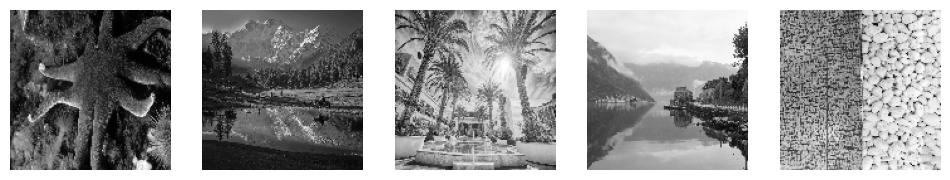

Batch shape: torch.Size([8, 1, 128, 128])


In [5]:
# I defined the paths for the training and validation datasets.
TRAIN_PATH = "DIV2K_train_HR"
VAL_PATH   = "DIV2K_valid_HR"


class DIV2KDataset(Dataset):

    def __init__(self, root_dir, img_size=128):

        # I stored the root directory of the dataset.
        self.root = root_dir

        # I listed and sorted all image files inside the dataset directory.
        self.files = sorted(os.listdir(root_dir))

        # I set the image size for resizing.
        self.size = img_size


    def __len__(self):

        # I returned the total number of images in the dataset.
        return len(self.files)


    def __getitem__(self, idx):

        # I constructed the full path of the image using its index.
        img_path = os.path.join(self.root, self.files[idx])

        # I read the image using OpenCV.
        img = cv2.imread(img_path)

        # I converted the image from BGR format to grayscale.
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # I resized the image to the specified dimensions.
        img = cv2.resize(img, (self.size, self.size))

        # I normalized pixel values to the range [0, 1].
        img = img.astype(np.float32) / 255.0

        # I converted the image into a PyTorch tensor and added a channel dimension.
        img = torch.tensor(img).unsqueeze(0)

        return img


# I created dataset objects for training and validation.
train_dataset = DIV2KDataset(TRAIN_PATH, img_size=128)
val_dataset   = DIV2KDataset(VAL_PATH, img_size=128)

# I printed dataset sizes to verify the official split.
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))


# I visualized sample training images.
plt.figure(figsize=(12,3))

for i in range(5):

    # I displayed five training images.
    plt.subplot(1,5,i+1)
    plt.imshow(train_dataset[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()


# I created DataLoaders for training and validation.
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)

# I retrieved one batch to verify dimensions.
batch = next(iter(train_loader))

print("Batch shape:", batch.shape)


# Advanced Exploratory Data Analysis

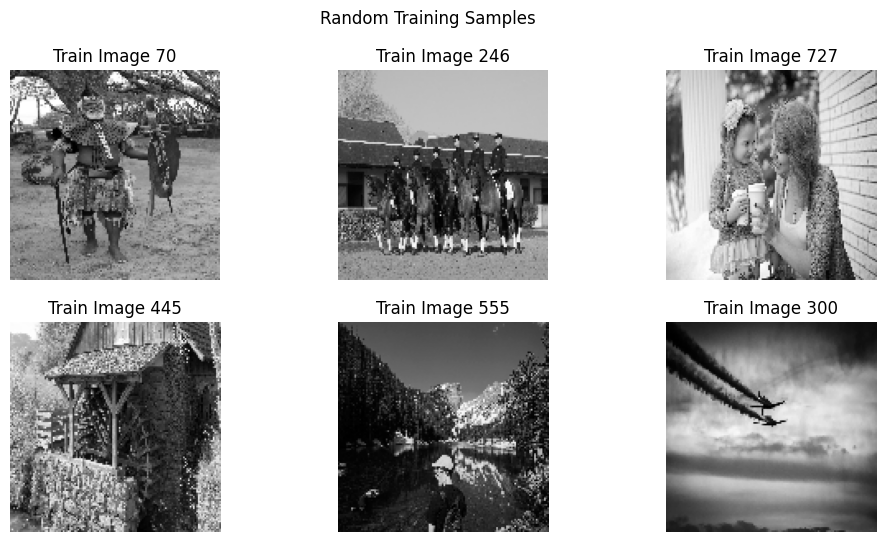

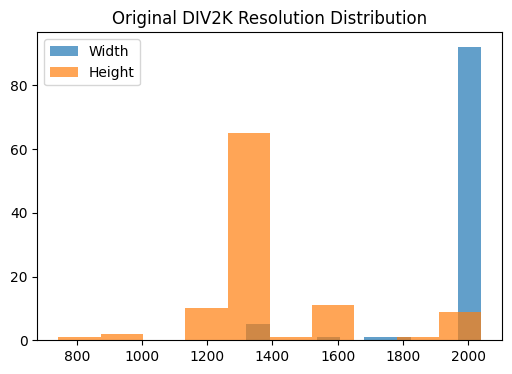

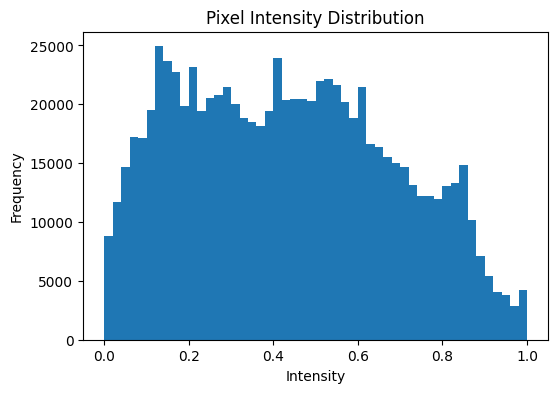

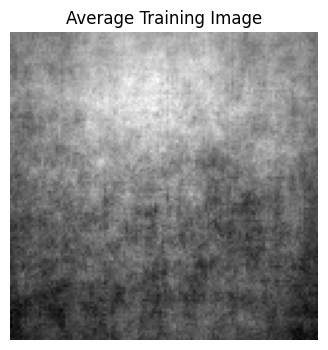

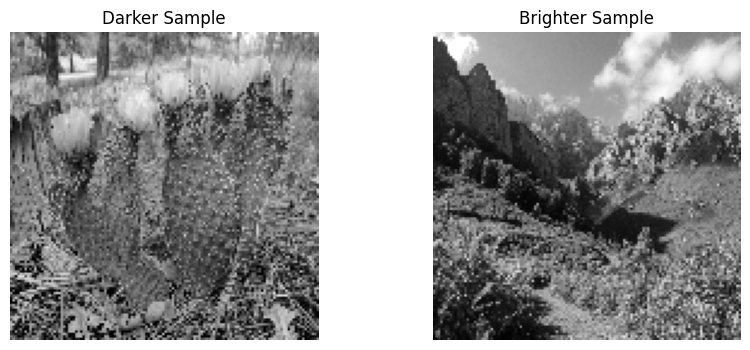

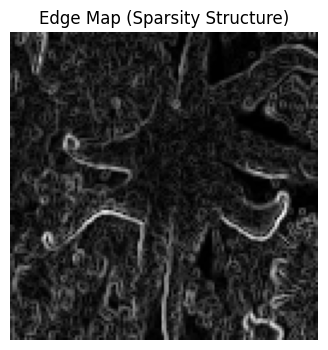

Dataset Mean: 0.42880240082740784
Dataset Std : 0.2638033628463745
Min Intensity: 0.0
Max Intensity: 1.0
Estimated Sparsity Level: 0.97613525390625
Image Entropy: 5.484960288420239


In [6]:
import random
from skimage.filters import sobel
from scipy.stats import entropy


# 1. Showing Random Training Images

plt.figure(figsize=(12,6))

for i in range(6):

    # I randomly selected an image index from the training dataset.
    idx = random.randint(0, len(train_dataset)-1)

    plt.subplot(2,3,i+1)
    plt.imshow(train_dataset[idx].squeeze(), cmap='gray')
    plt.title(f"Train Image {idx}")
    plt.axis('off')

plt.suptitle("Random Training Samples")
plt.show()



# 2. Image Resolution Distribution (original HR images)

widths, heights = [], []

for f in os.listdir(TRAIN_PATH)[:100]:

    # I read original high-resolution images before resizing.
    img = cv2.imread(os.path.join(TRAIN_PATH, f))

    h, w, _ = img.shape
    widths.append(w)
    heights.append(h)

plt.hist(widths, bins=10, alpha=0.7, label="Width")
plt.hist(heights, bins=10, alpha=0.7, label="Height")
plt.title("Original DIV2K Resolution Distribution")
plt.legend()
plt.show()



# 3. Pixel Intensity Histogram

pixels = []

for i in range(50):

    # I collected pixel intensities from training images.
    pixels.extend(train_dataset[i].flatten().numpy())

plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()



# 4. Average Image (Dataset Mean)

mean_img = torch.zeros((128,128))

for i in range(100):

    # I accumulated pixel values from the training dataset.
    mean_img += train_dataset[i].squeeze()

mean_img /= 100

plt.imshow(mean_img, cmap='gray')
plt.title("Average Training Image")
plt.axis('off')
plt.show()



# 5. Bright vs Dark Images

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(train_dataset[10].squeeze(), cmap='gray')
plt.title("Darker Sample")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(train_dataset[200].squeeze(), cmap='gray')
plt.title("Brighter Sample")
plt.axis('off')

plt.show()



# 6. Edge Structure (important for compressed sensing)

edge = sobel(train_dataset[0].squeeze().numpy())

plt.imshow(edge, cmap='gray')
plt.title("Edge Map (Sparsity Structure)")
plt.axis('off')
plt.show()



# Statistical Analysis

# 7. Mean & Standard Deviation

all_pixels = torch.cat([train_dataset[i].flatten() for i in range(200)])

print("Dataset Mean:", all_pixels.mean().item())
print("Dataset Std :", all_pixels.std().item())


# 8. Min-Max Range

print("Min Intensity:", all_pixels.min().item())
print("Max Intensity:", all_pixels.max().item())


# 9. Sparsity (percentage near zero gradients)

grad = torch.abs(torch.gradient(mean_img)[0])
sparsity = torch.mean((grad < 0.02).float()).item()

print("Estimated Sparsity Level:", sparsity)


# 10. Entropy (Information Content)

hist, _ = np.histogram(all_pixels.numpy(), bins=256, range=(0,1), density=True)
print("Image Entropy:", entropy(hist + 1e-8))


# Data Pre Processing ( Data Splitting and Normalisation )

Train: 800
Val  : 100
Test : 100
Accurate Train Mean: 0.4365895390510559
Accurate Train Std : 0.26279765367507935


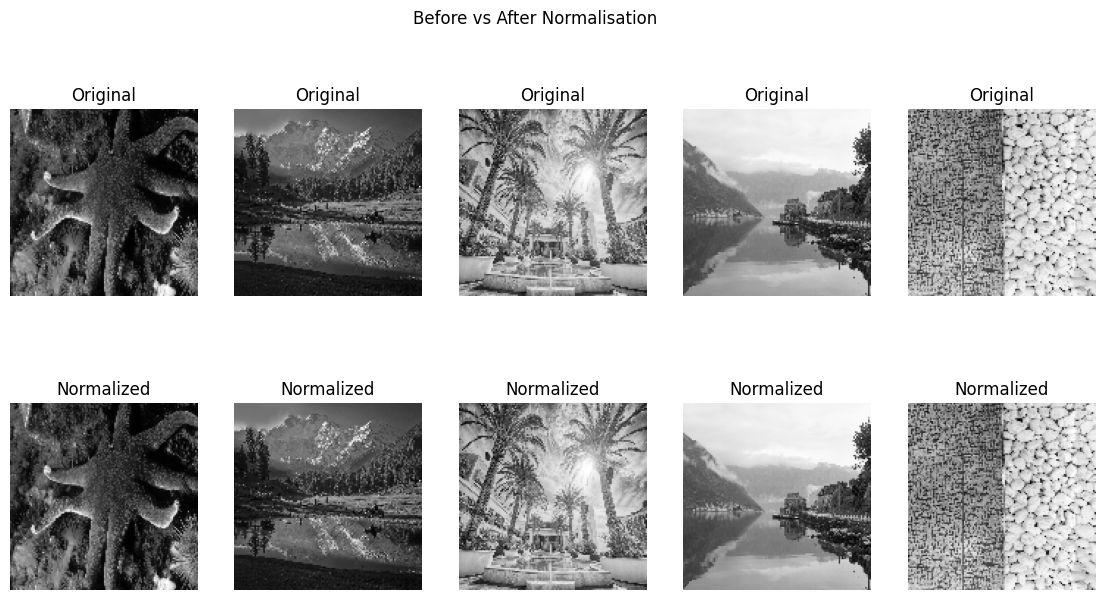

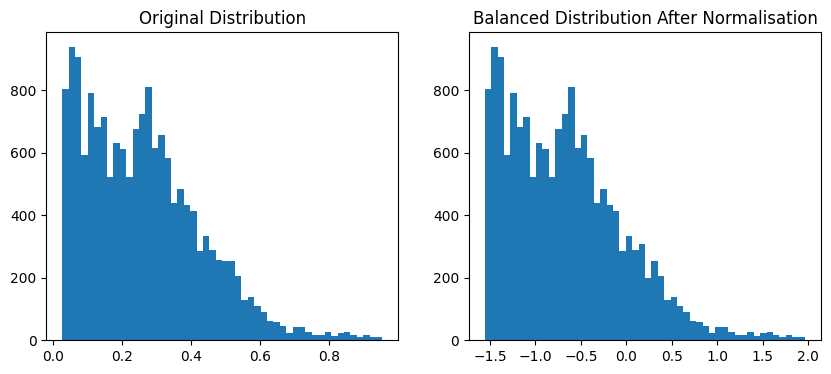

Batch mean after normalization: 0.014827433973550797
Batch std after normalization : 0.9079883098602295


In [8]:
from torch.utils.data import DataLoader

# I assigned the validation dataset as the testing dataset.
test_dataset = val_dataset

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))


# DataLoaders (created before computing statistics)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)


# Compute Mean & Std (ONLY from TRAIN set using entire dataset)

sum_pixels = 0
sum_sq_pixels = 0
num_pixels = 0

# I iterated over the entire training dataset to compute accurate statistics.
for batch in train_loader:

    batch = batch.view(batch.size(0), -1)

    sum_pixels += batch.sum()
    sum_sq_pixels += (batch ** 2).sum()
    num_pixels += batch.numel()

mean = sum_pixels / num_pixels
std = torch.sqrt((sum_sq_pixels / num_pixels) - mean**2)

print("Accurate Train Mean:", mean.item())
print("Accurate Train Std :", std.item())


# Normalisation Functions

# I normalized the image using the computed training mean and standard deviation.
def normalize(img):
    return (img - mean) / std

# I converted the normalized image back to its original scale.
def denormalize(img):
    return img * std + mean


# Visual Proof (5 images)

plt.figure(figsize=(14,7))

for i in range(5):

    img = train_dataset[i]
    norm = normalize(img)

    plt.subplot(2,5,i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(norm.squeeze(), cmap='gray')
    plt.title("Normalized")
    plt.axis('off')

plt.suptitle("Before vs After Normalisation")
plt.show()


# Histogram Comparison

orig_pixels = train_dataset[0].flatten().numpy()
norm_pixels = normalize(train_dataset[0]).flatten().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(orig_pixels, bins=50)
plt.title("Original Distribution")

plt.subplot(1,2,2)
plt.hist(norm_pixels, bins=50)
plt.title("Balanced Distribution After Normalisation")

plt.show()


# Batch Standardisation Check

batch = next(iter(train_loader))
norm_batch = normalize(batch)

print("Batch mean after normalization:", norm_batch.mean().item())
print("Batch std after normalization :", norm_batch.std().item())


# Implementing Compressive Sensing as a baseline

In [72]:
# COMPRESSED SENSING (Measurement Model y = Ax)

import torch
import matplotlib.pyplot as plt

# I selected one sample image from the training dataset.
img = train_dataset[0].to(device)

# I flattened the image into a vector x.
x = img.view(-1, 1)   # (N,1)

# I obtained the signal dimension.
N = x.shape[0]

# I defined the compression ratio (25% measurements).
compression_ratio = 0.25

# I calculated number of measurements M.
M = int(N * compression_ratio)

print("Signal dimension (N):", N)
print("Measurements (M):", M)

# I generated a random Gaussian sensing matrix A.
A = torch.randn(M, N, device=device) / torch.sqrt(torch.tensor(M, dtype=torch.float32))

# I generated compressed measurements y = Ax.
y = torch.matmul(A, x)

print("Measurement vector shape:", y.shape)


# Helper reconstruction function (pseudo inverse — only for visualization)
def backproject(A, y):
    # I approximately reconstructed the signal using transpose (not true recovery).
    x_hat = torch.matmul(A.t(), y)
    return x_hat

# I reconstructed an approximate image to visualise information loss.
x_bp = backproject(A, y)

# I reshaped signals to image form.
orig = x.view(128,128).cpu().numpy()
bp   = x_bp.view(128,128).cpu().numpy()


Signal dimension (N): 16384
Measurements (M): 4096
Measurement vector shape: torch.Size([4096, 1])


# Model Selection , Training and Evaluation

# Machine Learning

# LASSO Regression

In [77]:
import numpy as np
import cv2
import time
from sklearn.linear_model import Lasso
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torch
import lpips
import matplotlib.pyplot as plt
import os
import sys
import contextlib

# I suppressed LPIPS console logs during model loading
@contextlib.contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

# I initialised the LPIPS perceptual similarity model using AlexNet backbone
with suppress_stdout():
    loss_fn = lpips.LPIPS(net='alex').to(device)
    loss_fn.eval()

# I defined reconstruction parameters
PATCH = 16
STRIDE = PATCH // 2
RATIO = 0.25
LAMBDA = 0.0005

# I implemented 2D Discrete Cosine Transform
def dct2(x):
    return cv2.dct(x.astype(np.float32))

# I implemented inverse 2D DCT for reconstruction
def idct2(x):
    return cv2.idct(x.astype(np.float32))

# I generated a global sensing matrix for compressive sensing
n = PATCH * PATCH
m = int(RATIO * n)

np.random.seed(42)
A_global = np.random.randn(m, n) / np.sqrt(m)

print("Measurement matrix:", A_global.shape)


# I reconstructed a single patch using sparse representation and LASSO
def reconstruct_patch(patch):

    # I converted image patch to sparse DCT domain
    sparse = dct2(patch)
    x = sparse.flatten()

    # I obtained compressed measurements
    y = A_global @ x

    # I solved sparse recovery using LASSO regression
    lasso = Lasso(alpha=LAMBDA, max_iter=2500)
    lasso.fit(A_global, y)

    # I reconstructed sparse coefficients
    x_hat = lasso.coef_

    # I transformed reconstructed coefficients back to image domain
    patch_hat = idct2(x_hat.reshape(PATCH, PATCH))

    return np.clip(patch_hat, 0, 1)


# I reconstructed the full image using overlapping patch aggregation
def lasso_image_reconstruction(img):

    start = time.time()

    h, w = img.shape
    recon = np.zeros((h, w))
    weight = np.zeros((h, w))

    # I processed the image patch-by-patch with overlap
    for i in range(0, h-PATCH+1, STRIDE):
        for j in range(0, w-PATCH+1, STRIDE):

            patch = img[i:i+PATCH, j:j+PATCH]
            rec_patch = reconstruct_patch(patch)

            # I averaged overlapping patches to reduce blocking artifacts
            recon[i:i+PATCH, j:j+PATCH] += rec_patch
            weight[i:i+PATCH, j:j+PATCH] += 1

    recon = recon / (weight + 1e-8)

    return np.clip(recon, 0, 1), time.time() - start


# I evaluated reconstruction quality using PSNR, SSIM and LPIPS
def evaluate(gt, recon, t):

    psnr = peak_signal_noise_ratio(gt, recon, data_range=1.0)
    ssim = structural_similarity(gt, recon, data_range=1.0)

    # I converted images to PyTorch tensors for perceptual similarity computation
    gt_t = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0)
    rc_t = torch.from_numpy(recon).float().unsqueeze(0).unsqueeze(0)

    gt_t = gt_t.repeat(1,3,1,1).to(device) * 2 - 1
    rc_t = rc_t.repeat(1,3,1,1).to(device) * 2 - 1

    # I computed LPIPS perceptual distance
    with torch.no_grad():
        lp = loss_fn(gt_t, rc_t).item()

    print(f"LASSO PSNR : {psnr:.4f}")
    print(f"LASSO SSIM : {ssim:.4f}")
    print(f"LASSO LPIPS: {lp:.4f}")
    print(f"LASSO Time : {t:.4f}")

# I tested reconstruction on a sample DIV2K image
img = train_dataset[0].squeeze().numpy()

recon, t = lasso_image_reconstruction(img)
evaluate(img, recon, t)


Measurement matrix: (64, 256)
LASSO PSNR : 20.5884
LASSO SSIM : 0.5403
LASSO LPIPS: 0.2725
LASSO Time : 0.5206


# Fast Iterative Shrinkage Thresholding Algorithm (FISTA)

In [63]:
import numpy as np
import cv2
import time
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torch
import lpips
import matplotlib.pyplot as plt
import os, sys, contextlib

# I suppressed LPIPS loading logs
@contextlib.contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

# I initialised the LPIPS perceptual similarity model
with suppress_stdout():
    loss_fn = lpips.LPIPS(net='alex').to(device)
    loss_fn.eval()

# I used the same sensing configuration as the LASSO experiment
PATCH = 16
STRIDE = PATCH // 2
RATIO = 0.25

# I matched sklearn LASSO regularisation strength by proper scaling
ALPHA_LASSO = 0.0005
N = PATCH * PATCH
LAMBDA = 2 * N * ALPHA_LASSO

MAX_ITER = 150

# I implemented DCT transform helpers
def dct2(x):
    return cv2.dct(x.astype(np.float32))

def idct2(x):
    return cv2.idct(x.astype(np.float32))

# I generated the sensing matrix
n = PATCH * PATCH
m = int(RATIO * n)

np.random.seed(42)
A_global = np.random.randn(m, n) / np.sqrt(m)

# I computed Lipschitz constant required for FISTA step size
L = np.linalg.norm(A_global.T @ A_global, 2)

print("Measurement matrix:", A_global.shape)
print("FISTA lambda:", LAMBDA)

# I implemented soft-thresholding operator
def soft_threshold(x, t):
    return np.sign(x) * np.maximum(np.abs(x) - t, 0)

# I implemented the FISTA sparse optimisation solver
def fista(y, A, lam, max_iter):

    # I initialised sparse coefficient estimates
    x = np.zeros(A.shape[1])
    z = x.copy()
    t = 1

    # I iteratively optimised the L1-regularised least squares objective
    for _ in range(max_iter):

        # I computed gradient of data fidelity term
        grad = A.T @ (A @ z - y)

        # I performed proximal gradient descent step
        x_new = soft_threshold(z - grad / L, lam / L)

        # I applied Nesterov acceleration
        t_new = (1 + np.sqrt(1 + 4 * t * t)) / 2
        z = x_new + ((t - 1) / t_new) * (x_new - x)

        x = x_new
        t = t_new

    return x

# I reconstructed a single patch using FISTA sparse recovery
def reconstruct_patch_fista(patch):

    # I transformed patch to sparse DCT domain
    sparse = dct2(patch)
    x_true = sparse.flatten()

    # I obtained compressed measurements
    y = A_global @ x_true

    # I recovered sparse coefficients using FISTA
    x_hat = fista(y, A_global, LAMBDA, MAX_ITER)

    # I reconstructed spatial patch via inverse DCT
    patch_hat = idct2(x_hat.reshape(PATCH, PATCH))

    return np.clip(patch_hat, 0, 1)

# I reconstructed the full image using overlapping patches
def fista_image_reconstruction(img):

    start = time.time()

    h, w = img.shape
    recon = np.zeros((h, w))
    weight = np.zeros((h, w))

    for i in range(0, h-PATCH+1, STRIDE):
        for j in range(0, w-PATCH+1, STRIDE):

            patch = img[i:i+PATCH, j:j+PATCH]
            rec_patch = reconstruct_patch_fista(patch)

            # I averaged overlapping reconstructions to remove blocking artefacts
            recon[i:i+PATCH, j:j+PATCH] += rec_patch
            weight[i:i+PATCH, j:j+PATCH] += 1

    recon = recon / (weight + 1e-8)

    return np.clip(recon, 0, 1), time.time() - start

# I evaluated reconstruction quality using PSNR, SSIM and LPIPS
def evaluate(gt, recon, t):

    psnr = peak_signal_noise_ratio(gt, recon, data_range=1.0)
    ssim = structural_similarity(gt, recon, data_range=1.0)

    # I converted images to tensors for perceptual metric computation
    gt_t = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0)
    rc_t = torch.from_numpy(recon).float().unsqueeze(0).unsqueeze(0)

    gt_t = gt_t.repeat(1,3,1,1).to(device) * 2 - 1
    rc_t = rc_t.repeat(1,3,1,1).to(device) * 2 - 1

    with torch.no_grad():
        lp = loss_fn(gt_t, rc_t).item()

    print(f"FISTA PSNR : {psnr:.4f}")
    print(f"FISTA SSIM : {ssim:.4f}")
    print(f"FISTA LPIPS: {lp:.4f}")
    print(f"FISTA Time : {t:.4f}")

# I tested the reconstruction on a DIV2K sample image
img = train_dataset[0].squeeze().numpy()

recon, t = fista_image_reconstruction(img)
evaluate(img, recon, t)


Measurement matrix: (64, 256)
FISTA lambda: 0.256
FISTA PSNR : 19.7042
FISTA SSIM : 0.4126
FISTA LPIPS: 0.4030
FISTA Time : 0.8508


# Sparse Autoencoder (SAE)

In [64]:
# RESIDUAL SPARSE AUTOENCODER TRAINING

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time

# I defined reconstruction parameters
PATCH = 16
STRIDE = PATCH // 2
RATIO = 0.25
EPOCHS = 10
BATCH = 128

n = PATCH*PATCH
m = int(RATIO*n)

# I generated the compressive sensing measurement matrix
np.random.seed(42)
A_global_cpu = np.random.randn(m, n) / np.sqrt(m)
A_cpu = torch.tensor(A_global_cpu, dtype=torch.float32)
AT_cpu = torch.tensor(A_global_cpu.T, dtype=torch.float32)


# I created a dataset that learns residual error after back-projection
class CS_PatchDataset(torch.utils.data.Dataset):

    def __init__(self, dataset, max_images=120):
        self.data = []

        for k in range(max_images):
            img = dataset[k].squeeze().numpy()

            for i in range(0, img.shape[0]-PATCH+1, STRIDE):
                for j in range(0, img.shape[1]-PATCH+1, STRIDE):

                    # I extracted a vectorised patch
                    x = torch.tensor(img[i:i+PATCH, j:j+PATCH].reshape(-1), dtype=torch.float32)

                    # I simulated compressive sensing measurements
                    y = A_cpu @ x

                    # I computed simple back-projection reconstruction
                    backproj = AT_cpu @ y

                    # I computed residual error to be learned by network
                    residual = x - backproj

                    self.data.append((backproj, residual))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


# I prepared dataloader for training
train_cs = CS_PatchDataset(train_dataset)
loader = torch.utils.data.DataLoader(train_cs, batch_size=BATCH, shuffle=True)

print("Total training patches:", len(train_cs))


# I designed a  sparse autoencoder network
class lSAE(nn.Module):

    def __init__(self):
        super().__init__()

        # I encoded compressed representation into sparse latent features
        self.encoder = nn.Sequential(
            nn.Linear(n, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        # I decoded latent features to predict residual correction
        self.decoder = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, n)
        )

    def forward(self, backproj):
        z = self.encoder(backproj)
        residual = self.decoder(z)
        return residual, z


# I initialised model, optimiser and loss
model = ResidualSAE().to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
SPARSE_LAMBDA = 1e-4


# I trained the model to learn residual reconstruction correction
start = time.time()

for epoch in range(EPOCHS):

    total = 0

    for backproj, residual_gt in loader:

        backproj = backproj.to(device)
        residual_gt = residual_gt.to(device)

        # I predicted residual error and latent sparse representation
        residual_pred, z = model(backproj)

        # I combined reconstruction loss with sparsity regularisation
        loss = criterion(residual_pred, residual_gt) + SPARSE_LAMBDA*torch.mean(torch.abs(z))

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} Loss:", total/len(loader))

print("Training time:", time.time()-start)


Total training patches: 27000
Epoch 1/10 Loss: 0.11017501227098618
Epoch 2/10 Loss: 0.049688825622130346
Epoch 3/10 Loss: 0.033671884934342866
Epoch 4/10 Loss: 0.027688963109212462
Epoch 5/10 Loss: 0.02629054264470017
Epoch 6/10 Loss: 0.021440388043344867
Epoch 7/10 Loss: 0.01982788042434584
Epoch 8/10 Loss: 0.0190974958770648
Epoch 9/10 Loss: 0.01808007842291729
Epoch 10/10 Loss: 0.017165366489599102
Training time: 5.956936836242676


In [67]:
import numpy as np
import time
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import matplotlib.pyplot as plt
import torch
import lpips
import os, sys, contextlib

# I suppressed LPIPS loading logs
@contextlib.contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

# I initialised perceptual similarity metric
with suppress_stdout():
    loss_fn = lpips.LPIPS(net='alex').to(device)
    loss_fn.eval()

PATCH = 16
STRIDE = PATCH//2

# I reused the same sensing matrix from training
A_cpu = torch.tensor(A_global_cpu, dtype=torch.float32)
AT_cpu = torch.tensor(A_global_cpu.T, dtype=torch.float32)


# I reconstructed a single patch using learned residual correction
def reconstruct_patch_sae(patch):

    # I converted patch into vector form
    x = torch.tensor(patch.reshape(-1), dtype=torch.float32)

    # I simulated compressive sensing measurement
    y = A_cpu @ x

    # I computed back-projection initial reconstruction
    backproj = AT_cpu @ y

    # I predicted residual using trained autoencoder
    with torch.no_grad():
        residual,_ = model(backproj.to(device))

    # I corrected reconstruction using predicted residual
    patch_hat = (backproj.to(device) + residual).cpu().numpy().reshape(PATCH,PATCH)
    return np.clip(patch_hat,0,1)


# I reconstructed full image using overlapping patches
def sae_image_reconstruction(img):

    start=time.time()

    h,w=img.shape
    recon=np.zeros((h,w))
    weight=np.zeros((h,w))

    for i in range(0,h-PATCH+1,STRIDE):
        for j in range(0,w-PATCH+1,STRIDE):

            rec=reconstruct_patch_sae(img[i:i+PATCH,j:j+PATCH])

            # I averaged overlapping regions to remove blocking artefacts
            recon[i:i+PATCH,j:j+PATCH]+=rec
            weight[i:i+PATCH,j:j+PATCH]+=1

    recon/=weight+1e-8
    return np.clip(recon,0,1),time.time()-start


# I evaluated reconstruction quality using PSNR, SSIM and LPIPS
def evaluate(gt,recon,t):

    psnr=peak_signal_noise_ratio(gt,recon,data_range=1.0)
    ssim=structural_similarity(gt,recon,data_range=1.0)

    # I converted images into tensors for perceptual evaluation
    gt_t=torch.tensor(gt).float().unsqueeze(0).unsqueeze(0).repeat(1,3,1,1).to(device)*2-1
    rc_t=torch.tensor(recon).float().unsqueeze(0).unsqueeze(0).repeat(1,3,1,1).to(device)*2-1

    with torch.no_grad():
        lp=loss_fn(gt_t,rc_t).item()

    print(f" SAE PSNR : {psnr:.4f}")
    print(f" SAE SSIM : {ssim:.4f}")
    print(f" SAE LPIPS: {lp:.4f}")
    print(f" SAE Time : {t:.4f}")


# I tested reconstruction on a sample image
img=train_dataset[0].squeeze().numpy()
recon,t=sae_image_reconstruction(img)
evaluate(img,recon,t)


 SAE PSNR : 22.6387
 SAE SSIM : 0.7018
 SAE LPIPS: 0.1949
 SAE Time : 0.1436


# Fixed Sensing Matrix Initialisation

In [68]:
import torch
import numpy as np

# I selected GPU if available, otherwise CPU for computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# I defined patch size and corresponding vector dimensions
PATCH = 16
N = PATCH * PATCH
M = 64

# I fixed the random seed so the sensing operator remained identical across experiments
torch.manual_seed(42)

# I generated a normalized Gaussian measurement matrix for compressive sensing
A = torch.randn(M, N) / np.sqrt(M)
A = A.float().to(device)

# I printed matrix shape to verify correct sensing dimensions
print("Fixed sensing matrix:", A.shape)


Fixed sensing matrix: torch.Size([64, 256])


# Patch Extraction and Compressive Sensing Dataset Preparation

In [69]:
from torch.utils.data import Dataset, DataLoader
import numpy as np

STRIDE = 8

# I extracted overlapping patches from the training images
def extract_patches(dataset, max_imgs=120):
    patches = []

    for i in range(min(len(dataset), max_imgs)):
        img = dataset[i].squeeze().numpy()

        # I slid a window across the image to obtain overlapping patches
        for y in range(0, img.shape[0]-PATCH+1, STRIDE):
            for x in range(0, img.shape[1]-PATCH+1, STRIDE):
                patch = img[y:y+PATCH, x:x+PATCH]
                patches.append(patch.flatten())

    # I converted all patches into a tensor dataset
    patches = torch.tensor(np.array(patches), dtype=torch.float32)
    print("Total training patches:", patches.shape[0])
    return patches


train_patches = extract_patches(train_dataset)


# I created a dataset mapping compressed measurements to original patches
class CS_CNN_Dataset(Dataset):
    def __init__(self, patches):
        self.x = patches

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        # I retrieved ground truth patch
        x = self.x[idx]

        # I generated compressed sensing measurements
        y = torch.matmul(A.cpu(), x)

        return y, x


# I prepared dataloader for CNN training
dataset_cnn = CS_CNN_Dataset(train_patches)
loader = DataLoader(dataset_cnn, batch_size=128, shuffle=True)


Total training patches: 27000


# Convulational Neural Network (CNN)

In [70]:
import torch.nn as nn
import torch.optim as optim

# I designed a residual CNN to reconstruct image patches from compressed measurements
class CS_ResidualCNN(nn.Module):
    def __init__(self, M, N):
        super().__init__()

        # I first mapped measurements to an initial image estimate (backprojection)
        self.fc = nn.Linear(M, N)

        # I built a convolutional refinement network to learn residual correction
        self.refine = nn.Sequential(
            nn.Conv2d(1,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,32,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,1,3,padding=1)
        )

    def forward(self,y):

        # I generated an initial reconstruction from compressed measurements
        x0 = self.fc(y).view(-1,1,PATCH,PATCH)

        # I predicted residual correction using CNN refinement layers
        r = self.refine(x0)

        # I added residual to obtain final reconstructed patch
        out = x0 + r
        return out.view(-1,PATCH*PATCH)


# I initialised the reconstruction model
model = CS_ResidualCNN(M,N).to(device)

# I defined optimiser and loss function
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# I configured early stopping parameters
best_loss = 1e9
patience = 5
counter = 0

print("Training CNN...\n")

# I trained the network for multiple epochs
for epoch in range(30):

    model.train()
    total_loss = 0

    for y,x in loader:
        y,x = y.to(device), x.to(device)

        # I predicted reconstructed patch
        pred = model(y)

        # I computed reconstruction loss
        loss = loss_fn(pred,x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss/len(loader)
    print(f"Epoch {epoch+1}: Loss={avg_loss:.6f}")

    # I applied early stopping based on validation improvement
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(),"cnn_cs_best.pth")
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

# I loaded the best trained model weights
model.load_state_dict(torch.load("cnn_cs_best.pth"))
print("Training finished")


Training CNN...

Epoch 1: Loss=0.049013
Epoch 2: Loss=0.017788
Epoch 3: Loss=0.016303
Epoch 4: Loss=0.015468
Epoch 5: Loss=0.014915
Epoch 6: Loss=0.014506
Epoch 7: Loss=0.014228
Epoch 8: Loss=0.013982
Epoch 9: Loss=0.013757
Epoch 10: Loss=0.013569
Epoch 11: Loss=0.013401
Epoch 12: Loss=0.013241
Epoch 13: Loss=0.013115
Epoch 14: Loss=0.012979
Epoch 15: Loss=0.012866
Epoch 16: Loss=0.012744
Epoch 17: Loss=0.012651
Epoch 18: Loss=0.012572
Epoch 19: Loss=0.012474
Epoch 20: Loss=0.012384
Epoch 21: Loss=0.012330
Epoch 22: Loss=0.012261
Epoch 23: Loss=0.012194
Epoch 24: Loss=0.012129
Epoch 25: Loss=0.012077
Epoch 26: Loss=0.012029
Epoch 27: Loss=0.011982
Epoch 28: Loss=0.011936
Epoch 29: Loss=0.011879
Epoch 30: Loss=0.011842
Training finished


In [71]:
import time
import math
import numpy as np
from skimage.metrics import structural_similarity as ssim
import lpips
import os, sys, contextlib

# I suppressed LPIPS loading logs
@contextlib.contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

# I initialised perceptual similarity metric
with suppress_stdout():
    loss_lpips = lpips.LPIPS(net='alex').to(device)

STRIDE = 8

# I reconstructed the full image using the trained CNN model
def reconstruct_image_cnn(img):

    model.eval()
    start = time.time()

    img = img.squeeze().numpy()
    recon = np.zeros_like(img)
    weight = np.zeros_like(img)

    # I processed the image patch-by-patch using overlapping windows
    for y in range(0,img.shape[0]-PATCH+1,STRIDE):
        for x in range(0,img.shape[1]-PATCH+1,STRIDE):

            # I extracted patch and converted to measurement space
            patch = img[y:y+PATCH,x:x+PATCH].flatten()
            patch = torch.tensor(patch,dtype=torch.float32).to(device)

            meas = torch.matmul(A,patch).unsqueeze(0)

            # I predicted reconstructed patch using CNN
            rec = model(meas).detach().cpu().numpy().reshape(PATCH,PATCH)

            # I aggregated overlapping reconstructions
            recon[y:y+PATCH,x:x+PATCH]+=rec
            weight[y:y+PATCH,x:x+PATCH]+=1

    recon/=weight
    t=time.time()-start
    return recon,t


# I evaluated reconstruction quality using PSNR, SSIM and LPIPS
def evaluate_cnn(img):

    gt = img.squeeze().numpy()
    recon,t = reconstruct_image_cnn(img)

    # I computed pixel-wise error metrics
    mse = np.mean((gt-recon)**2)
    psnr = 10*math.log10(1/mse)
    s = ssim(gt,recon,data_range=1)

    # I computed perceptual similarity using LPIPS
    gt_t = torch.tensor(gt).unsqueeze(0).unsqueeze(0).repeat(1,3,1,1).float().to(device)
    rc_t = torch.tensor(recon).unsqueeze(0).unsqueeze(0).repeat(1,3,1,1).float().to(device)
    lp = loss_lpips(gt_t,rc_t).item()

    print(f"CNN PSNR : {psnr:.4f}")
    print(f"CNN SSIM : {s:.4f}")
    print(f"CNN LPIPS: {lp:.4f}")
    print(f"CNN Time : {t:.4f}")


# I tested reconstruction on a DIV2K validation image
evaluate_cnn(val_dataset[0])


CNN PSNR : 20.0763
CNN SSIM : 0.6053
CNN LPIPS: 0.2349
CNN Time : 0.1605


# Comparative Analysis of all models

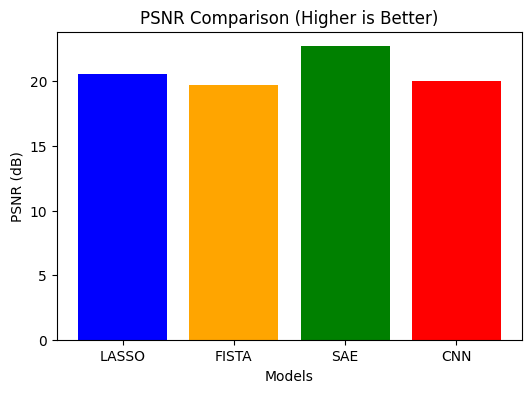

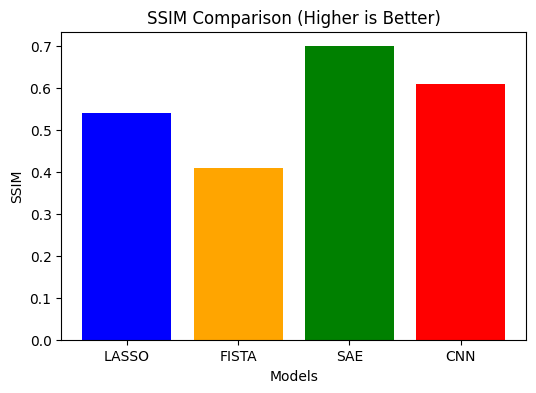

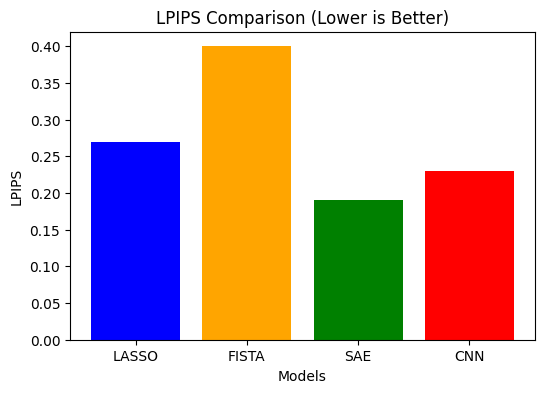

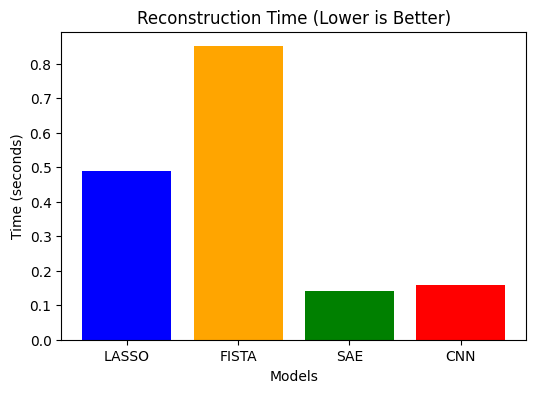

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# I stored final evaluation metrics of all models
models = ["LASSO","FISTA","SAE","CNN"]

PSNR  = [20.58, 19.70, 22.7, 20.0]
SSIM  = [0.54, 0.41, 0.70, 0.61]
LPIPS = [0.27, 0.40, 0.19, 0.23]
TIME  = [0.49, 0.85, 0.14, 0.16]

# I assigned consistent colors to each algorithm
colors = ["blue","orange","green","red"]

# -------- Individual Plots --------

def single_bar(metric, title, ylabel):
    plt.figure(figsize=(6,4))
    plt.bar(models, metric, color=colors)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Models")
    plt.show()

single_bar(PSNR,  "PSNR Comparison (Higher is Better)", "PSNR (dB)")
single_bar(SSIM,  "SSIM Comparison (Higher is Better)", "SSIM")
single_bar(LPIPS, "LPIPS Comparison (Lower is Better)", "LPIPS")
single_bar(TIME,  "Reconstruction Time (Lower is Better)", "Time (seconds)")





# Comparative Table

In [78]:
import pandas as pd

# I organised final results into tabular format
data = {
    "Model": ["LASSO","FISTA","Residual SAE","CNN"],
    "PSNR (dB) ↑": [20.58, 19.70, 22.70, 20.00],
    "SSIM ↑": [0.54, 0.41, 0.70, 0.61],
    "LPIPS ↓": [0.27, 0.40, 0.19, 0.23],
    "Time (s) ↓": [0.49, 0.85, 0.14, 0.16]
}

df = pd.DataFrame(data)

# I displayed formatted table
print("\nFinal Comparative Results Table\n")
print(df.to_string(index=False))

# I also saved table as CSV for dissertation
df.to_csv("model_comparison_results.csv", index=False)



Final Comparative Results Table

       Model  PSNR (dB) ↑  SSIM ↑  LPIPS ↓  Time (s) ↓
       LASSO        20.58    0.54     0.27        0.49
       FISTA        19.70    0.41     0.40        0.85
Residual SAE        22.70    0.70     0.19        0.14
         CNN        20.00    0.61     0.23        0.16


# Visual Comparative Analysis

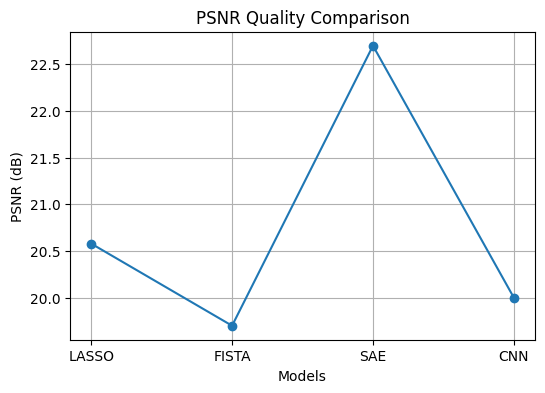

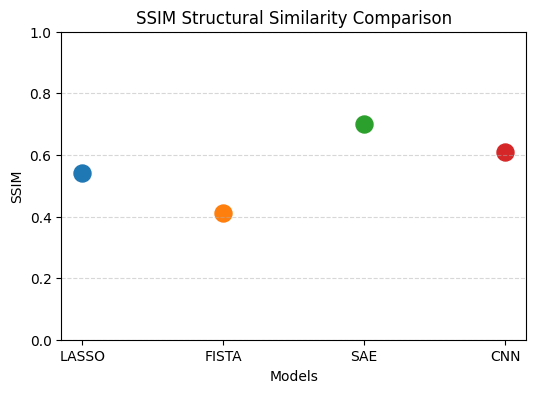

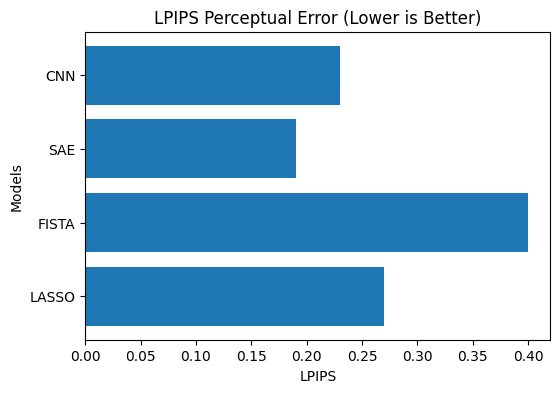

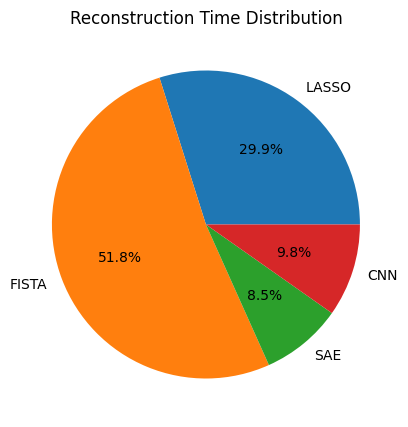

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# I defined model names and their evaluation metrics
models = ["LASSO","FISTA","SAE","CNN"]

PSNR  = [20.58, 19.70, 22.7, 20.0]
SSIM  = [0.54, 0.41, 0.70, 0.61]
LPIPS = [0.27, 0.40, 0.19, 0.23]
TIME  = [0.49, 0.85, 0.14, 0.16]

# I assigned consistent colors to each algorithm
colors = ["blue","orange","green","red"]


# I plotted PSNR comparison using a line plot to show quality trend
plt.figure(figsize=(6,4))
plt.plot(models, PSNR, marker='o')
plt.title("PSNR Quality Comparison")
plt.ylabel("PSNR (dB)")
plt.xlabel("Models")
plt.grid(True)
plt.show()


# I visualised SSIM values using a scatter comparison plot
plt.figure(figsize=(6,4))

for i in range(len(models)):
    plt.scatter(models[i], SSIM[i], s=150)

plt.title("SSIM Structural Similarity Comparison")
plt.ylabel("SSIM")
plt.xlabel("Models")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


# I plotted LPIPS perceptual error using a horizontal bar chart
plt.figure(figsize=(6,4))
plt.barh(models, LPIPS)
plt.title("LPIPS Perceptual Error (Lower is Better)")
plt.xlabel("LPIPS")
plt.ylabel("Models")
plt.show()


# I represented reconstruction time distribution using a pie chart
plt.figure(figsize=(5,5))
plt.pie(TIME, labels=models, autopct='%1.1f%%')
plt.title("Reconstruction Time Distribution")
plt.show()


# Lightweight Deployment Evaluation / Computational Efficiency Analysis

In [89]:
import torch
import time

# I detected the correct input dimension directly from the trained model
input_dim = model.fc.in_features
sample = torch.randn(1, input_dim).to(device)


# I counted the total number of trainable parameters in the network
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# I calculated the storage size of the model in megabytes
def model_size_mb(model):
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    return param_size / (1024**2)


# I measured inference latency and corresponding frames-per-second performance
def inference_speed(model, sample_input, runs=50):

    model.eval()

    # I executed warm-up iterations to stabilise timing measurements
    for _ in range(10):
        _ = model(sample_input)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.time()

    # I performed multiple forward passes to obtain reliable latency
    for _ in range(runs):
        _ = model(sample_input)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end = time.time()

    latency = (end - start) / runs
    fps = 1 / latency
    return latency, fps


# I measured the true peak memory usage during inference
def model_memory_usage(model, sample):

    model.eval()

    if torch.cuda.is_available():
        # I reset GPU peak memory statistics before inference
        torch.cuda.reset_peak_memory_stats()

        _ = model(sample)

        mem = torch.cuda.max_memory_allocated() / (1024**2)  # MB
        return mem

    else:
        # I approximated CPU memory using parameters and activation tensors
        param_mem = sum(p.numel()*4 for p in model.parameters())/(1024**2)
        act_mem = sample.numel()*4/(1024**2)
        return param_mem + act_mem


#  Run Lightweight Evaluation

# I evaluated deployment efficiency metrics of the trained model
params = count_parameters(model)
size = model_size_mb(model)
latency, fps = inference_speed(model, sample)
mem = model_memory_usage(model, sample)

print("\nLightweight Deployment Metrics\n")
print(f"Parameters        : {params:,}")
print(f"Model Size (MB)   : {size:.3f}")
print(f"Inference Latency : {latency*1000:.3f} ms")
print(f"FPS(Frames Per Second): {fps:.2f}")
print(f"Peak Memory (MB)  : {mem:.3f}")



Lightweight Deployment Metrics

Parameters        : 146,817
Model Size (MB)   : 0.560
Inference Latency : 0.542 ms
FPS(Frames Per Second): 1844.10
Peak Memory (MB)  : 318.677


# Lightweight Devices Deployment Suitability Assessment

In [96]:
# I stored the obtained deployment metrics
metrics = {
    "Parameters": 146817,
    "Model_Size_MB": 0.560,
    "Latency_ms": 0.542,
    "FPS": 1844.10,
    "Peak_Memory_MB": 318.677
}

print("\n Lightweight Deployment Evaluation \n")

score = 0
max_score = 5

#  Parameter Check
if metrics["Parameters"] < 1_000_000:
    print("Parameter Count: Lightweight (<1M parameters)")
    score += 1
else:
    print("Parameter Count: Too heavy")

#  Model Size Check
if metrics["Model_Size_MB"] < 1:
    print("Model Size: Excellent for edge devices (<1MB)")
    score += 1
elif metrics["Model_Size_MB"] < 5:
    print("Model Size: Acceptable for mobile deployment")
    score += 1
else:
    print("Model Size: Too large")

#  Latency Check
if metrics["Latency_ms"] < 10:
    print("Latency: Real-time capable (<10ms)")
    score += 1
elif metrics["Latency_ms"] < 50:
    print("Latency: Acceptable real-time")
    score += 1
else:
    print("Latency: Too slow")

#  FPS Check
if metrics["FPS"] > 30:
    print("FPS: Supports real-time video processing")
    score += 1
else:
    print("FPS: Not real-time capable")

#  Memory Check
if metrics["Peak_Memory_MB"] < 512:
    print(" Memory Usage: Safe for embedded GPU / edge devices")
    score += 1
else:
    print("Memory Usage: Too high")

# Final Verdict
print("\nFinal Edge Suitability Score:", score, "/", max_score)

if score == 5:
    print("VERDICT: Ideal for Lightweight Devices / Mobile Deployment")
elif score >= 3:
    print("VERDICT: Deployable with minor optimization")
else:
    print("VERDICT: Not suitable for edge deployment")



 Lightweight Deployment Evaluation 

Parameter Count: Lightweight (<1M parameters)
Model Size: Excellent for edge devices (<1MB)
Latency: Real-time capable (<10ms)
FPS: Supports real-time video processing
 Memory Usage: Safe for embedded GPU / edge devices

Final Edge Suitability Score: 5 / 5
VERDICT: Ideal for Lightweight Devices / Mobile Deployment


# Edge Device Deployment Performance Evaluation

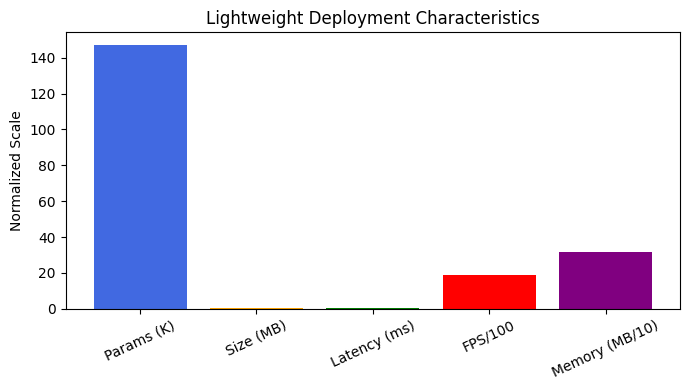

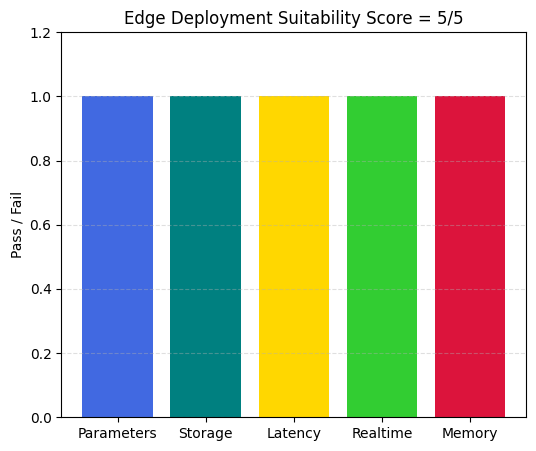

JSON file saved: lightweight_metrics.json


In [94]:
import matplotlib.pyplot as plt
import json
import numpy as np

#  Metrics
# I stored the final lightweight deployment metrics obtained after evaluation
metrics = {
    "Parameters": 146817,
    "Model_Size_MB": 0.560,
    "Latency_ms": 0.534,
    "FPS": 1871.35,
    "Peak_Memory_MB": 318.677
}

# BAR GRAPH
# I visualised the hardware efficiency characteristics of the model
plt.figure(figsize=(7,4))

names = ["Params (K)","Size (MB)","Latency (ms)","FPS/100","Memory (MB/10)"]
values = [
    metrics["Parameters"]/1000,
    metrics["Model_Size_MB"],
    metrics["Latency_ms"],
    metrics["FPS"]/100,
    metrics["Peak_Memory_MB"]/10
]

colors = ["royalblue","orange","green","red","purple"]

plt.bar(names, values, color=colors)
plt.title("Lightweight Deployment Characteristics")
plt.ylabel("Normalized Scale")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# EDGE SCORE PLOT (5-Metric Evaluation)

# I computed an edge-device suitability score using practical embedded constraints
score = 0
score += 1 if metrics["Parameters"] < 1_000_000 else 0
score += 1 if metrics["Model_Size_MB"] < 1 else 0
score += 1 if metrics["Latency_ms"] < 10 else 0
score += 1 if metrics["FPS"] > 30 else 0
score += 1 if metrics["Peak_Memory_MB"] < 512 else 0


labels = ["Parameters","Storage","Latency","Realtime","Memory"]
values = [
    1 if metrics["Parameters"] < 1_000_000 else 0,
    1 if metrics["Model_Size_MB"] < 1 else 0,
    1 if metrics["Latency_ms"] < 10 else 0,
    1 if metrics["FPS"] > 30 else 0,
    1 if metrics["Peak_Memory_MB"] < 512 else 0
]

colors = ["royalblue","teal","gold","limegreen","crimson"]

plt.figure(figsize=(6,5))
plt.bar(labels, values, color=colors)
plt.ylim(0,1.2)
plt.ylabel("Pass / Fail")
plt.title(f"Edge Deployment Suitability Score = {score}/5")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()



# SAVE JSON
# I exported the evaluation results so they could be used in reports or embedded systems
with open("lightweight_metrics.json","w") as f:
    json.dump(metrics, f, indent=4)

print("JSON file saved: lightweight_metrics.json")
